In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO


In [ ]:
# Concatenate tsv files containing the number of masked positions in cons and masked

# Access the total median cat list and add the results to the file
final_path = Path("/nfs/research/goldman/anoufa/data/dpca/masked_pos.tsv")

folder_path = Path("/nfs/research/goldman/anoufa/data/dpca/gen_metrics/")


# Generate a new file to reset it
median_depth_list_total = [0] * 13
mean_depth_list_total = [0] * 13
het_sites_list_total = [[0] * 9 for _ in range(4)]
prop_below_depth_list_total = [[0] * 20 for _ in range(2)]
length_list_total = [0] * 13
amplicons_length_list_total = [0] * 20
dropout_lengths_list_total = [0] * 400

for pkl_file in folder_path.glob("*.pkl"):
    batch_id = pkl_file.stem.split("_")[-1]
    print(f"Processing batch {batch_id}")
    
    path = folder_path / f"storing_file_{batch_id}.pkl"
    
    # Load the data
    with open(path, "rb") as f:
        storing_list = pickle.load(f)
        
    median_depth_list = storing_list[0]
    mean_depth_list = storing_list[1]
    het_sites_list = storing_list[2]
    prop_below_depth_list = storing_list[3]
    length_list = storing_list[4]
    amplicons_length_list = storing_list[5]
    dropout_lengths_list = storing_list[6]
    
    # Remove the files
    path.unlink()
    
    # Add the results to the total lists
    median_depth_list_total = [x + y for x, y in zip(median_depth_list_total, median_depth_list)]
    mean_depth_list_total = [x + y for x, y in zip(mean_depth_list_total, mean_depth_list)]
    
    length_list_total = [x + y for x, y in zip(length_list_total, length_list)]
    
    for i in range(4):
        het_sites_list_total[i] = [x + y for x, y in zip(het_sites_list_total[i], het_sites_list[i])]
        
    for i in range(2):
        prop_below_depth_list_total[i] = [x + y for x, y in zip(prop_below_depth_list_total[i], prop_below_depth_list[i])]
    
    amplicons_length_list_total = [x + y for x, y in zip(amplicons_length_list_total, amplicons_length_list)]
    dropout_lengths_list_total = [x + y for x, y in zip(dropout_lengths_list_total, dropout_lengths_list)]
    


storing_list_total = [median_depth_list_total, mean_depth_list_total, het_sites_list_total, prop_below_depth_list_total, length_list_total, amplicons_length_list_total, dropout_lengths_list_total]

# Save the total median depth list
with open(final_path, "wb") as f:
    pickle.dump(storing_list_total, f)

In [2]:
# Compare NC_045512.2 with MAPLE ref seq

path_nc = "/nfs/research/goldman/anoufa/data/NC_045512.2.fasta"

path_maple = "/nfs/research/goldman/anoufa/data/MAPLE_input/pango-consensus-sequences_level_4_20230228.maple"

nc_seq = SeqIO.read(path_nc, "fasta")

with open(path_maple, "r") as f:
    f.readline()  # skip header
    # maple seq is in the second line
    maple_seq = f.readline().strip()


nc_seq = str(nc_seq.seq)

In [4]:
nc_seq

# Save nc_seq in a FASTA file

path = "/nfs/research/goldman/anoufa/data/NC_045512.2_flat.fasta"

with open(path, "w") as f:
    f.write(f">NC_045512.2\n{nc_seq}\n")

In [13]:
import pickle
path_1 = "/nfs/research/goldman/anoufa/data/MAPLE_input/variant_mut_dict_NC_045512.2.pickle"

path_2 = "/nfs/research/goldman/anoufa/data/MAPLE_input/variant_mut_dict_2_NC_045512.2.pickle"

with open(path_1, "rb") as f:
    variant_mut_dict = pickle.load(f)
    
with open(path_2, "rb") as f:
    variant_mut_dict_2 = pickle.load(f)
    
# Check if the two dictionaries are equal
for key in variant_mut_dict:
    if key not in variant_mut_dict_2:
        print(f"Key {key} not found in variant_mut_dict_2")
    elif variant_mut_dict[key] != variant_mut_dict_2[key]:
        print(f"Values for key {key} are different: {variant_mut_dict[key]} vs {variant_mut_dict_2[key]}")

In [ ]:
# Look for the closest variant for each sample

In [5]:
def convert_maple_file(path_maple, ref_seq):
    """
    Convert the MAPLE file to another MAPLE file with a different reference sequence.
    """
    with open(path_maple, "r") as f:
        f.readline()  # skip header
        maple_ref = f.readline().strip()
        in_seq = False
        for line in tqdm(f):
            if line.startswith(">"):
                seq_name = line.strip()
                in_seq = True
        

In [7]:
# Open the MAPLE file, iterate on the variants, store the positions of the mutations, check if both references match at those positions

positions_set = set()

with open(path_maple, "r") as f:
    
    for line in f:
        if line.startswith(">") or line.startswith("AAA") or line.startswith("-"):
            continue
        
        line = line.strip()
        try:
            nt, pos = line.split('\t')
            
        except ValueError:
            print(line)
        pos = int(pos)
        
        positions_set.add(pos)
        


In [1]:
ref_seq

NameError: name 'ref_seq' is not defined

In [9]:
maple_file = "/nfs/research/goldman/anoufa/data/MAPLE_input/pango-consensus-sequences_level_4_20230228_NC_045512.2.maple"
ref_seq = nc_seq  # Use the NC_045512.2 sequence as the reference
variant_mut_dict = {}
# Read the file and extract the vcf
with open(maple_file, "r") as f:
    
    f.readline()  # skip header
    ref_seq = f.readline().strip()
    current_variant = []
    for line in f:
        if line.startswith(">"):
            if current_variant:
                # Save the previous sequence
                variant_mut_dict[seq_name] = current_variant
            # Start a new sequence
            current_variant = []
            seq_name = line.strip()
        
        else:
            if line[0] in ["A", "C", "G", "T"]: # G	29847
                mut = line.split('\t')
                pos, nt = int(mut[1]), mut[0]
                ref_nt = ref_seq[pos - 1]  # MAPLE positions are 1-based
                mut = str(ref_nt) + str(pos) + str(nt)
                current_variant.append(mut)
    

In [11]:
variant_mut_dict

# Save the dictionary to a file
path_dic = "/nfs/research/goldman/anoufa/data/MAPLE_input/variant_mut_dict_NC_045512.2.pickle"
import pickle
with open(path_dic, "wb") as f:
    pickle.dump(variant_mut_dict, f)



In [5]:
# Open alignment file and read some lines

path = Path("/nfs/research/goldman/anoufa/data/dpca/batches/maple_alignment_batch0_1.0_0.1_0.3_800_masked.txt")


In [ ]:
def build_initial_write_file(path_ref_seq="/nfs/research/goldman/anoufa/data/NC_045512.2.fasta",
                             path_write_file="/nfs/research/goldman/anoufa/data/MAPLE_alignment.txt"):
    # Open the reference sequence fasta file,
    # retrieve the whole sequence as a string, lowercase it,
    # generate a MAPLE_alignment.txt file with the reference sequence
    with open(path_ref_seq, "r") as f:
        # Sequence starts at line 2
        ref_seq = "".join(line.strip() for line in f.readlines()[1:])
        ref_seq = ref_seq.lower()
        
    # Generate the MAPLE_alignment.txt file
    # with open(path_write_file, "w") as f:
    #     # Write the header
    #     f.write(">reference\n")
    #     # Write the sequence
    #     f.write(ref_seq)
    #     f.write("\n")
    
    return ref_seq

In [16]:
ref_vdn = build_initial_write_file()

In [15]:
# Replace "." with "0" in all the last columns, starting at total_depth
# Switch all columns with integer values (that are object for the moment) to int
# Add columns total_A, total_C, total_G, total_T that sums the counts of columns A and a, C and c, G and g, T and t
# Add column cons_nt_prop that computes the proportion of the consensus nucleotide in the reads
# Then we find which nucleotide is the consensus one using column Cons_nt
# and finally we compute total_cons_nt / clean_depth
# Cons_nt can be - so we have to handle this case (in this case we set the proportion to 1)

def compute_cons_nt_prop(row):
    
    if row["Clean_depth"] == 0:
        return 1
    else:
        # print(row["Cons_nt"], row["total_reads"])
        cons_nt = row["Cons_nt"]
        if cons_nt == "-":
            return row['prop_D']
    
        elif cons_nt not in ["A", "C", "G", "T"]:
            return 1
        
        prop = "prop_" + cons_nt
        return row[prop]


In [21]:
def prepare_df(qc_df):
    qc_df.iloc[:, 8:] = qc_df.iloc[:, 8:].replace(".", "0")
    
    for col in qc_df.columns:
        if qc_df[col].dtype == "object":
            try:
                qc_df[col] = qc_df[col].astype(int)
            except ValueError:
                pass
    
    qc_df["total_A"] = qc_df["A"] + qc_df["a"]
    qc_df["total_C"] = qc_df["C"] + qc_df["c"]
    qc_df["total_G"] = qc_df["G"] + qc_df["g"]
    qc_df["total_T"] = qc_df["T"] + qc_df["t"]
    qc_df["total_I"] = qc_df["I"] + qc_df["i"]
    qc_df["total_D"] = qc_df["D"] + qc_df["d"]
    
    # Calculate the proportion of all the nucleotides
    qc_df["prop_A"] = qc_df["total_A"] / qc_df["Clean_depth"]
    qc_df["prop_C"] = qc_df["total_C"] / qc_df["Clean_depth"]
    qc_df["prop_G"] = qc_df["total_G"] / qc_df["Clean_depth"]
    qc_df["prop_T"] = qc_df["total_T"] / qc_df["Clean_depth"]
    qc_df["prop_I"] = qc_df["total_I"] / qc_df["Clean_depth"]
    qc_df["prop_D"] = qc_df["total_D"] / qc_df["Clean_depth"]
    
    qc_df["c_a_prop"] = qc_df.apply(compute_cons_nt_prop, axis=1)
    
    return qc_df

def find_potential_contamination(qc_df, het_thr=0.9, depth_thr=0.2, prop_under_depth_thr=0.4, typical_depth_thr=500):
    """
    Find potential contamination in a DataFrame based on the proportion of the consensus nucleotide.

    Parameters:
        df (pd.DataFrame): Input DataFrame containing sequencing data.
        het_threshold (float): Threshold for heterozygosity. Default is 0.9.
        depth_thr (float): Threshold for depth amplicon dropout. Default is 0.5.

    Returns:
        pd.DataFrame: DataFrame with rows that have potential contamination.
    """
    
    qc_df = prepare_df(qc_df)

    typical_depth = qc_df["Clean_depth"].median()
    depth_int_thr = typical_depth * depth_thr
    prop_pos_under_depth_thr = qc_df[qc_df["Clean_depth"] < depth_int_thr].shape[0] / qc_df.shape[0]

    # Filter rows where the proportion is below the threshold
    contaminated_rows = qc_df[
        (qc_df["c_a_prop"] < het_thr) &
        (qc_df["Clean_depth"] < depth_int_thr) &
        (qc_df["Clean_depth"] > 0)
    ]
    
    # Measure the proportion of positions below the depth threshold    
    # If this proportion is too high, we can consider that the sequencing quality is too poor to draw any conclusions
    
    if prop_pos_under_depth_thr > prop_under_depth_thr or typical_depth < typical_depth_thr:
        # Empty the contaminated_rows DataFrame
        contaminated_rows = pd.DataFrame(columns=qc_df.columns)

    return contaminated_rows, typical_depth, prop_pos_under_depth_thr

In [17]:
# First analysis of the conflicting sites of DRR272391
# 17 sites with cons_nt_prop < 0.95, most of them have a prop around 0.9
# 3 sites have a prop much lower (0.52, 0.77 and 0.83)
# 0.52 is labeled as HET (heterozygous?) the two others have passed.
# What would be interesting now would be to have a bank of consensus genome and a way to check the
# proximity between the conflicting sites and other genomes to find the potential contaminant
# This would be a purely algorithmic approach that could serve as a baseline.

In [18]:
source_dir = Path("../../../zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Reads/")  # Base directory containing RR** folders

def generate_gz_file_pairs(source_dir: Path, top_folder='D', shuffle=False):
    """
    Yields (gz_file_path, new_filename) for matching .tsv.gz files in the specified folder.
    """
    pattern = f"{top_folder}/RR[0-9]*/[0-9][0-9]/[0-9][0-9]/vdn.v1.0.0/*.tsv.gz"
    
    if shuffle:
        files = list(source_dir.glob(pattern))
        np.random.shuffle(files)
    else:
        files = source_dir.glob(pattern)
    
    
    for gz_file in files:
        parts = gz_file.parts
        top_folder = parts[-6]     # e.g., "D"
        rr_num = parts[-5]         # from "RR****"
        sub1 = parts[-4]           # first subdirectory (e.g., "02")
        sub2 = parts[-3]           # second subdirectory (e.g., "03")
        read_name = f"{top_folder}{rr_num}{sub1}{sub2}"

        yield gz_file, read_name

In [18]:
# PERFORMANCE COMPARISON: GZIP + CSV VS PANDAS
import csv
import gzip
from collections import defaultdict

def read_tsv_gz_columns(file_path):
    columns = defaultdict(list)
    with gzip.open(file_path, mode='rt') as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            for key, value in row.items():
                columns[key].append(value)
    return dict(columns)



for tsv_gz, read_name in tqdm(generate_gz_file_pairs(source_dir, top_folder='D', shuffle=False)):    
    # Read the gzipped TSV file
    columns = read_tsv_gz_columns(tsv_gz)
        
for tsv, filename in tqdm(generate_gz_file_pairs(source_dir, top_folder='D')):
    # Get the filename without the path
    # print(f"Processing {filename}...")
    
    # Read the file
    df = pd.read_csv(
        tsv,       
        sep='\t',          
        compression='gzip',   
        low_memory=False,     
        on_bad_lines='warn' 
    )


301it [00:57,  5.22it/s]
301it [00:21, 13.86it/s]


In [7]:
# Let's try to run the function on all the DRR reads
# Get all the files in the directory VDN_READS

def generate_result_df(het_thr, depth_thr, pud_thr, med_dep_thr, top_folder='D'):

    result_list = []
    get_out=0
    for tsv, filename in tqdm(generate_gz_file_pairs(source_dir, top_folder=top_folder)):
        # Get the filename without the path
        # print(f"Processing {filename}...")
        
        # Read the file
        df = pd.read_csv(
            tsv,       
            sep='\t',          
            compression='gzip',   
            low_memory=False,     
            on_bad_lines='warn' 
        )
            
        # Find potential contamination
        contaminated_rows, typical_depth, prop_pos_under_depth_thr = find_potential_contamination(df,
            het_thr=het_thr,
            depth_thr=depth_thr,
            prop_under_depth_thr=pud_thr,
            typical_depth_thr=med_dep_thr
        )
        
        
        if contaminated_rows.empty:
            continue  # No need to do anything else

        # Store the number of conflicting sites, their position in the genome and the name of the read
        mut_count = len(contaminated_rows)
        positions = contaminated_rows["Ref_pos"].tolist()
        
        # We also want to build the minor allele sequence 
        # Look at the contaminated rows and get the second most frequent nucleotide in columns total_A, total_C, total_G, total_T
        counts = contaminated_rows[['total_A', 'total_C', 'total_T', 'total_G']].copy()
        cons_nuc_idx = contaminated_rows['Cons_nt'].apply(lambda x: f'total_{x}')
        # Set the most frequent nucleotide to -1
        for idx, col in cons_nuc_idx.items():
            counts.at[idx, col] = -1
        m_a_variants = counts.idxmax(axis=1).str.replace('total_', '')
        
        # Build the sequence by taking the consensus sequence (df['Cons_nt']) and replacing the positions of the minor allele
        cons_sequence = df['Cons_nt'].copy()
        cons_sequence_str = "".join(cons_sequence.tolist())
        
        cons_sequence.loc[positions] = m_a_variants.values
        m_a_sequence_str = "".join(cons_sequence)
        
        # Also output the sequence with N at the positions of the minor allele
        masked_sequence = df['Cons_nt'].copy()
        masked_sequence.loc[positions] = "N"
        masked_sequence_str = "".join(masked_sequence.tolist())
        
        # Build the list of the mutations in contaminated rows by concatenating cons_nt, position and minor allele
        mutations = []
        for i, row in contaminated_rows.iterrows():
            cons_nt = row['Cons_nt']
            pos = row['Ref_pos']
            m_a = m_a_variants[i]
            mutations.append(f"{cons_nt}{pos}{m_a}")
        
        # Save these as a tuple in a list
        result_list.append((filename, mut_count, mutations, int(typical_depth), float(prop_pos_under_depth_thr), masked_sequence_str, cons_sequence_str))
        
        get_out+=1
        # if get_out == 30:
        #     break

    result_list_df = pd.DataFrame(result_list, columns=["read_name", "het_count", "het_mutations", "typical_depth", "prop_pos_under_thr", "masked_sequence_str", "cons_sequence_str"])

    filename = "result_samples_" + top_folder + "_" + str(het_thr) + "_" + str(depth_thr) + "_" + str(pud_thr) + "_" + str(med_dep_thr) + ".csv"
    
    result_list_df.to_csv("../data/" + filename, index=False)

In [ ]:
# This really only gives us the heterozygous sites (and it is long to compute)
# This list might even miss some sites that are not heterozygous but are still contaminated.
# This list would really be useful to retrieve potential contaminant genomes using the minor alleles at these sites

# To do that we would need position and nucleotide of the minor allele for each of these sites.

# ATM in VDN the fasta files are not aligned to the reference genome.
# If I want to make a database out of VDN I need the aligned genomes.
# I'm quite sure that this already exists

generate_result_df(het_thr=1, depth_thr=0.10, pud_thr=0.2, med_dep_thr=600, top_folder='D')
# Load the csv
result_list_df = pd.read_csv("../data/result_samples_D_1_0.1_0.2_600.csv")


466it [02:58,  2.61it/s]


KeyboardInterrupt: 

In [38]:
result_list_df.info()

# NONE of the 20 samples with the highest number of heterozygous sites at low depth are present in Viridian taxonomy


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   read_name            77 non-null     object 
 1   het_count            77 non-null     int64  
 2   het_mutations        77 non-null     object 
 3   typical_depth        77 non-null     int64  
 4   prop_pos_under_thr   77 non-null     float64
 5   masked_sequence_str  77 non-null     object 
 6   cons_sequence_str    77 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 4.3+ KB


In [3]:
# Order by mut_count (descending)
result_list_df.sort_values(by="prop_pos_under_thr", ascending=True).head()


,read_name,het_count,het_mutations,typical_depth,prop_pos_under_thr,masked_sequence_str,cons_sequence_str
9,DRR321271,1,['T22016G'],1204,0.004715,--------------------------------------ACTTTCGA...,--------------------------------------ACTTTCGA...
74,DRR287340,3,"['T21861A', 'A21868G', 'C21871G']",1128,0.005050,---------------------------------AACCAACTTTCGA...,---------------------------------AACCAACTTTCGA...
61,DRR286890,7,"['A20347T', 'A20351T', 'A20355T', 'C20365A', '...",1004,0.005317,----------------------------------ACCAACTTTCGA...,----------------------------------ACCAACTTTCGA...
29,DRR402933,2,"['A10764C', 'C10765G']",1179,0.005617,--------------------------------CAACCAACTTTCGA...,--------------------------------CAACCAACTTTCGA...
23,DRR402900,7,"['A13780T', 'T13781C', 'C13784T', 'A13785T', '...",1157,0.005951,---------------------------------AACCAACTTTCGA...,---------------------------------AACCAACTTTCGA...


0it [00:00, ?it/s]

60it [00:25,  2.38it/s]


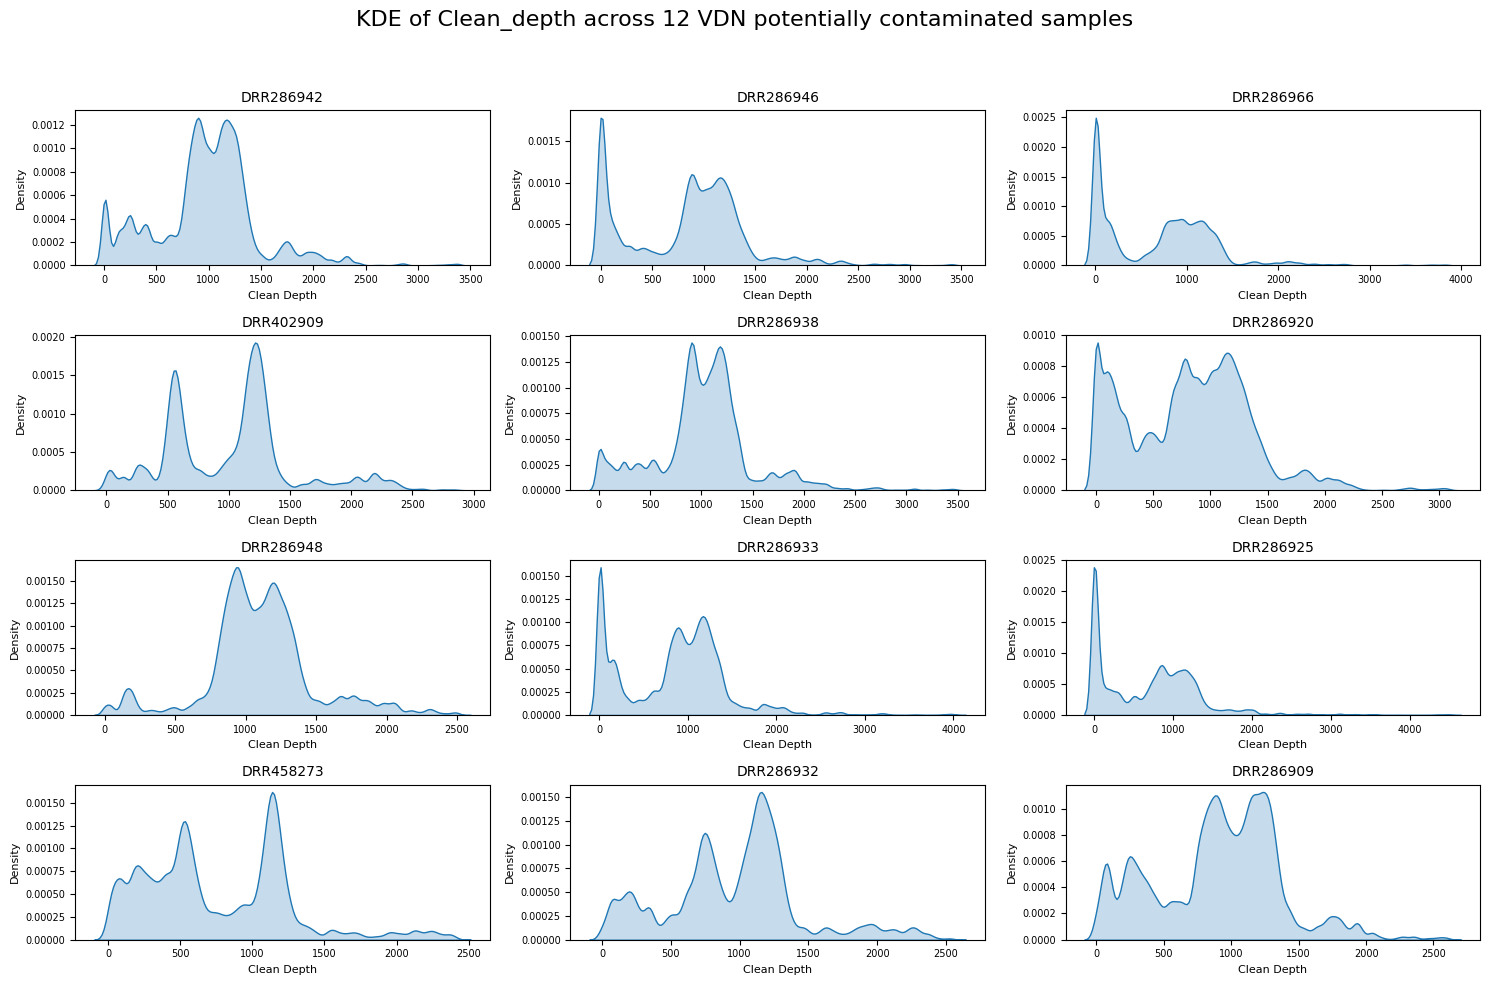

In [22]:
# Plot the distribution of Clean_depth on a grid of subplots (~12 samples)
# Set up grid layout: 4 rows, 3 columns = 12 plots
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.4)

count=0

for tsv, filename in tqdm(generate_gz_file_pairs(source_dir, shuffle=True)):
    qc_df = pd.read_csv(
        tsv,
        sep='\t',
        compression='gzip',
        low_memory=False,
        on_bad_lines='warn'
    )
    
    contaminated_rows, typical_depth, prop_pos_under_depth_thr = find_potential_contamination(qc_df,
                                                                                              het_thr=0.9,
                                                                                              depth_thr=0.1,
                                                                                              prop_under_depth_thr=0.3,
                                                                                              typical_depth_thr=500)
    
    if contaminated_rows.empty:
        continue  # No need to do anything else
    
    if count >= 12:
        break
    
    qc_df = prepare_df(qc_df)

    ax = axes.flatten()[count]

    sns.kdeplot(data=qc_df, x="Clean_depth", ax=ax, fill=True, bw_adjust=0.5)
    ax.set_title(filename, fontsize=10)
    ax.set_xlabel("Clean Depth", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.tick_params(axis='both', labelsize=7)
    count+=1


plt.suptitle("KDE of Clean_depth across 12 VDN potentially contaminated samples", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../figs/Clean_depth_kde_pcs.png")
plt.show()


# VDN sample we looked at seem to have spikes at ~500 ~1000 and ~2000 depths 
# We will consider dropout if the depth is below the ~500 spike.
# We will take 0.2 * median_depth as a threshold for dropout
# This result does not generalize to all the samples, and especially not to the ones with a lot of heterozygous sites


12it [00:05,  2.06it/s]


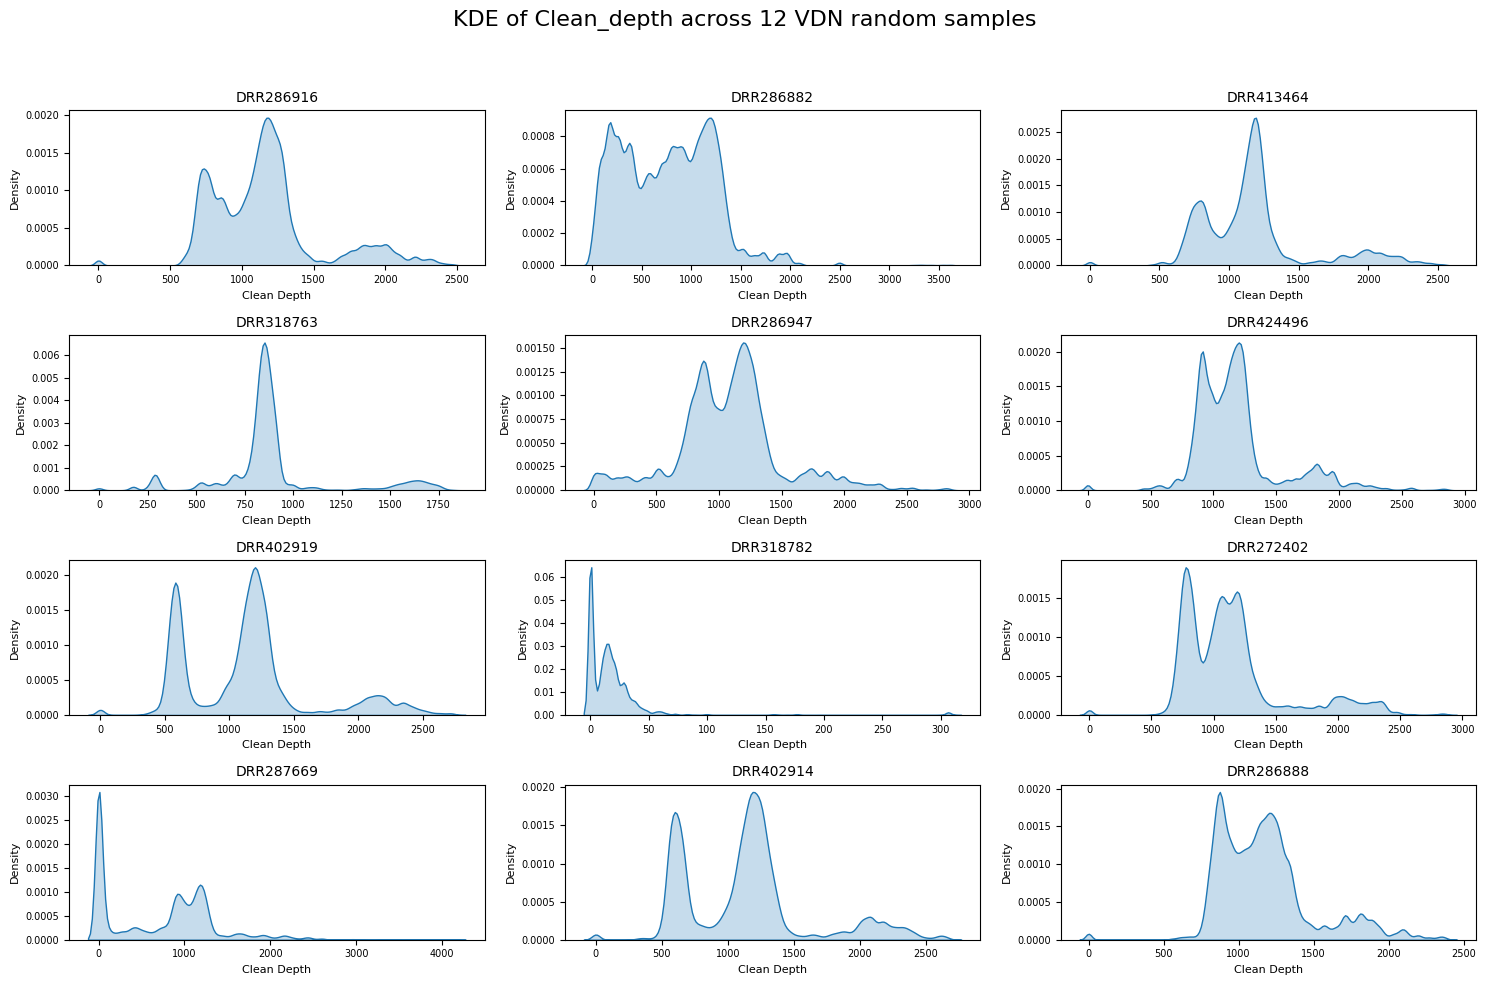

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.4)

count=0

for tsv, filename in tqdm(generate_gz_file_pairs(source_dir, shuffle=True)):
    qc_df = pd.read_csv(
        tsv,
        sep='\t',
        compression='gzip',
        low_memory=False,
        on_bad_lines='warn'
    )
    
    if count >= 12:
        break
    qc_df.iloc[:, 8:] = qc_df.iloc[:, 8:].replace(".", "0")
    
    for col in qc_df.columns:
        if qc_df[col].dtype == "object":
            try:
                qc_df[col] = qc_df[col].astype(int)
            except ValueError:
                pass

    ax = axes.flatten()[count]

    sns.kdeplot(data=qc_df, x="Clean_depth", ax=ax, fill=True, bw_adjust=0.5)
    ax.set_title(filename, fontsize=10)
    ax.set_xlabel("Clean Depth", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.tick_params(axis='both', labelsize=7)
    count+=1

plt.suptitle("KDE of Clean_depth across 12 VDN random samples", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../figs/Clean_depth_kde.png")
plt.show()

In [8]:
# Make fasta file of the masked sequences and the real sequences

# Store all the sequences in a fasta file

def save_sequences_to_fasta(result_list_df):
    records = []
    for filename, _, _, _, _, m_a_sequence_str, cons_sequence_str in result_list_df.itertuples(index=False):
        # Create a SeqRecord for the minor allele sequence
        minor_seq_record = SeqRecord(Seq(m_a_sequence_str), id=f"{filename}_masked", description="Masked sequence")
        records.append(minor_seq_record)
        
        # Create a SeqRecord for the consensus sequence
        cons_seq_record = SeqRecord(Seq(cons_sequence_str), id=f"{filename}_consensus", description="Consensus sequence")
        records.append(cons_seq_record)
    
    # Save all records to a fasta file
    SeqIO.write(records, "../data/masked_consensus_sequences.fasta", "fasta")
    
# Save the sequences to a fasta file
save_sequences_to_fasta(result_list_df)

In [24]:
# Nicola has identified some weird samples, let's look at them
# ERR10023445 SRR21457403 SRR21636214 SRR21635309 SRR22038159 

# First we import them

source_dir = Path("../../../zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Reads/")  # Base directory containing RR** folders

path_1 = Path("../../../zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Reads/E/RR1002/34/45/vdn.v1.0.0/qc.tsv.gz")
path_2 = Path("../../../zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Reads/S/RR2145/74/03/vdn.v1.0.0/qc.tsv.gz")
path_3 = Path("../../../zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Reads/S/RR2163/62/14/vdn.v1.0.0/qc.tsv.gz")
path_4 = Path("../../../zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Reads/S/RR2163/53/09/vdn.v1.0.0/qc.tsv.gz")
path_5 = Path("../../../zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Reads/S/RR2203/81/59/vdn.v1.0.0/qc.tsv.gz")

paths = [('ERR10023445', path_1), 
         ('SRR21457403', path_2), 
         ('SRR21636214', path_3), 
         ('SRR21635309', path_4), 
         ('SRR22038159', path_5)]

# Copy the files to the current directory
import shutil
import gzip
import os


for read, path in paths:
    # Get the filename without the path
    path_to_data = "../data/" + read + "_qc.tsv.gz"
    # Copy the file to the current directory
    shutil.copy(path, path_to_data)
    
    # unzip the file
    with gzip.open(path_to_data, 'rb') as f_in:
        with open(path_to_data[:-3], 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    # Remove the gz file
    # os.remove(path_to_data)

In [ ]:
result_list = []
het_thr = 1.01
depth_thr = 0.20
pud_thr = 1
med_dep_thr = 200

for read_name, tsv in tqdm(paths): 
    # Get the filename without the path
    # print(f"Processing {filename}...")
    
    # Read the file
    df = pd.read_csv(
        tsv,       
        sep='\t',          
        compression='gzip',   
        low_memory=False,     
        on_bad_lines='warn' 
    )
        
    # Find potential contamination
    contaminated_rows, typical_depth, prop_pos_under_depth_thr = find_potential_contamination(df,
        het_thr=het_thr,
        depth_thr=depth_thr,
        prop_under_depth_thr=pud_thr,
        typical_depth_thr=med_dep_thr
    )
    
    
    if contaminated_rows.empty:
        print(f"Sample {read_name} has no contaminated rows.")
        continue  # No need to do anything else

    # Store the number of conflicting sites, their position in the genome and the name of the read
    mut_count = len(contaminated_rows)
    positions = contaminated_rows["Ref_pos"].tolist()
    
    # We also want to build the minor allele sequence 
    # Look at the contaminated rows and get the second most frequent nucleotide in columns total_A, total_C, total_G, total_T
    counts = contaminated_rows[['total_A', 'total_C', 'total_T', 'total_G']].copy()
    cons_nuc_idx = contaminated_rows['Cons_nt'].apply(lambda x: f'total_{x}')
    # Set the most frequent nucleotide to -1
    for idx, col in cons_nuc_idx.items():
        counts.at[idx, col] = -1
    m_a_variants = counts.idxmax(axis=1).str.replace('total_', '')
    
    # Build the sequence by taking the consensus sequence (df['Cons_nt']) and replacing the positions of the minor allele
    cons_sequence = df['Cons_nt'].copy()
    cons_sequence_str = "".join(cons_sequence.tolist())
    
    # We have to make -1 to all the positions because they are 1 - 29903 but the sequence is 0 - 29902
    python_positions = [pos - 1 for pos in positions]
    cons_sequence.loc[python_positions] = m_a_variants.values
    # m_a_sequence_str = "".join(cons_sequence)
    
    # Also output the sequence with N at the positions of the minor allele
    masked_sequence = df['Cons_nt'].copy()
    masked_sequence.loc[python_positions] = "N"
    masked_sequence_str = "".join(masked_sequence.tolist())
    
    # Build the list of the potentially contaminated sites in contaminated rows by concatenating cons_nt, position and minor allele
    pot_cont_sites = []
    for i, row in contaminated_rows.iterrows():
        cons_nt = row['Cons_nt']
        pos = row['Ref_pos']
        m_a = m_a_variants[i]
        pot_cont_sites.append(f"{cons_nt}{pos}{m_a}")
    
    # Save these as a tuple in a list
    result_list.append((read_name, mut_count, pot_cont_sites, int(typical_depth), float(prop_pos_under_depth_thr), masked_sequence_str, cons_sequence_str))

result_list_df = pd.DataFrame(result_list, columns=["read_name", "het_count", "het_mutations", "typical_depth", "prop_pos_under_thr", "masked_sequence_str", "cons_sequence_str"])

filename = "result_concerning_samples_" + "_" + str(het_thr) + "_" + str(depth_thr) + "_" + str(pud_thr) + "_" + str(med_dep_thr) + ".csv"

result_list_df.to_csv("../data/" + filename, index=False)

100%|██████████| 5/5 [00:01<00:00,  2.50it/s]


In [ ]:
# Open the result file made on 100 samples that passed VDN qc and take a look at those.

result_df = pd.read_csv("../data/result_samples_100_1.1_0.1_0.2_900.csv")

result_df.describe()

,het_count,typical_depth,prop_pos_under_thr
count,58.000000,58.000000,58.000000
mean,799.551724,1081.413793,0.041274
std,777.563450,233.041374,0.037658
min,25.000000,908.000000,0.007558
25%,237.000000,954.250000,0.014271
50%,507.500000,990.000000,0.024078
75%,1136.500000,1142.500000,0.057118
max,3117.000000,2237.000000,0.194496


In [2]:
# This script should go over the tsv results of MAPLE sample placement and
# generate the distributions of the branch lengths for the three types of sequences
# (viridian, masked, random).

# The goal is to see whether the masked samples are closer to the tree than the viridian ones or not.

from pathlib import Path      
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

viridian_lengths = [0] * 9
masked_lengths = [0] * 9
random_lengths = [0] * 9

def bin_branch_lengths(length):
    """
    Bin the branch lengths into categories.
    """
    unit = 1/29903
    # One bin every 0.5 * unit until 4*unit+ (9 categories)
    
    if length < 0.5 * unit:
        return 0
    elif length < 1 * unit:
        return 1
    elif length < 1.5 * unit:
        return 2
    elif length < 2 * unit:
        return 3
    elif length < 2.5 * unit:
        return 4
    elif length < 3 * unit:
        return 5
    elif length < 3.5 * unit:
        return 6
    elif length < 4 * unit:
        return 7
    else:
        return 8
        

# Define the path to the folder containing the tsv files
folder_path = Path("/nfs/research/goldman/anoufa/data/MAPLE_output/")
unit = 1/29903

# Iterate over the tsv files in the folder
for file_path in folder_path.glob("*.tsv"):
    # Read the tsv file
    with open(file_path, "r") as file:
        lines = file.readlines()
    
    # Extract the sample lengths for the three types of sequences
    for line in lines[1:]:
        # Columns:  index   sample	                placements	                    optimizedBlengths (<topBlength>/<bottomBlength>/<sampleBlength>)   mutations
        # Example line: 0	consensus_ERR4239172	in2495143:0.9997103398863393	in2495143:(6.68997107947098e-05/0/0)	T10029C;G21618C;G22917T;A22995C;T23063A;A23604...
        
        # We are interested in the sampleBlengths of the placement with highest support.
        columns = line.strip().split("\t")
        sample = columns[0]
        placements = columns[1]
        if "empty possiblePlacements" in placements:
            continue
        optimizedBlengths = columns[2]
        mutations = columns[3]
        
        sampleBlength = optimizedBlengths.split(";")[0] # Get the first placement (highest support)
        sampleBlength = sampleBlength.split("/")[2] # We get this part 0)
        sampleBlength = sampleBlength[:-1] # Remove the last character (the closing parenthesis)
        sampleBlength = float(sampleBlength)
        
        if "consensus" in sample:
            viridian_lengths[bin_branch_lengths(sampleBlength)] += 1
        elif "masked" in sample:
            masked_lengths[bin_branch_lengths(sampleBlength)] += 1
        else:
            random_lengths[bin_branch_lengths(sampleBlength)] += 1

import plotly.express as px

len_cat = ["<0.5", "0.5-1", "1-1.5", "1.5-2", "2-2.5", "2.5-3", "3-3.5", "3.5-4", ">4"]

# Convert to long-form DataFrame
df = pd.DataFrame({
    "Category": len_cat * 3,
    "Count": viridian_lengths + masked_lengths + random_lengths,
    "Type": ["Viridian"] * len(len_cat) + ["Masked"] * len(len_cat) + ["Random"] * len(len_cat)
})

fig = px.bar(
    df,
    x="Category",
    y="Count",
    color="Type",
    barmode="group",
    title="Distribution of Branch Lengths for Viridian, Masked, and Random Sequences",
    labels={"Category": "Branch Length Categories"}
)

fig.update_layout(xaxis_tickangle=-45)
fig.write_image("../figs/branch_lengths_plotly.png")
fig.show()

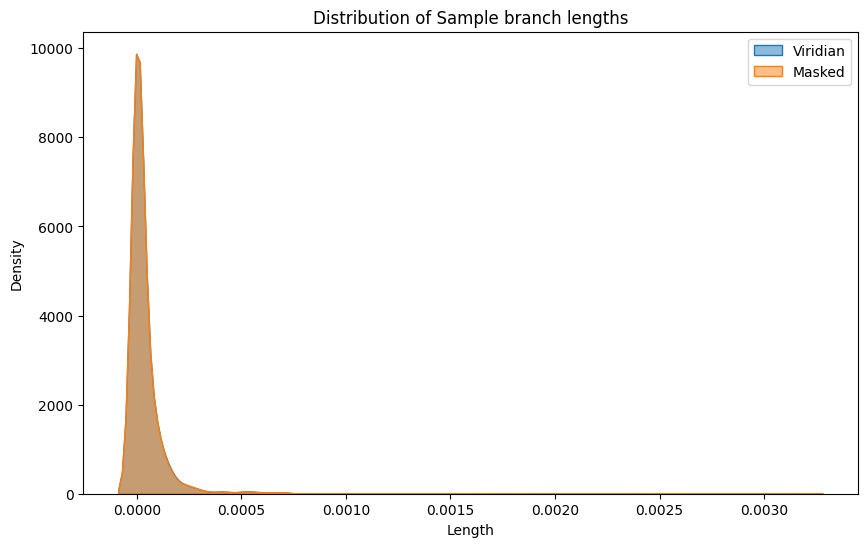

In [18]:
# Plot the distributions of the lengths of the three types of sequences on the same graph
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(viridian_lengths, label="Viridian", fill=True, alpha=0.5)
sns.kdeplot(masked_lengths, label="Masked", fill=True, alpha=0.5)
sns.kdeplot(random_lengths, label="Random", fill=True, alpha=0.5)
plt.title("Distribution of Sample branch lengths")
plt.xlabel("Length")
plt.ylabel("Density")
plt.legend()
plt.savefig("../figs/branch_lengths.png")
plt.show()



In [6]:
"""
Output a df with columns read_name and mutations.
mutations col should contain the mutations that appear in Viridian sample and NOT in masked sample.

Input df should have columns: read_name, sample_type, mutations.
"""
    
test_input_df = pd.DataFrame({
    "read_name": ["a31", "a31", "a31"],
    "sample_type": ["consensus", "masked", "random"],
    "mutations": [
        "A1234G;C5678T",
        "A1234G",
        "C5678T;A1234G"
    ]
})

df_mutations = test_input_df.groupby("read_name")["mutations"].apply(lambda x: ";".join(set(";".join(x).split(";")))).reset_index()
df_mutations.columns = ["read_name", "mutations"]
df_mutations

,read_name,mutations
0,a31,C5678T;A1234G


In [1]:
# CHECK THE OUTPUT FILE OF MAPLE SAMPLE PLACEMENT
from pathlib import Path
import pandas as pd

placement_result_path = Path("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements_results_3_5.tsv")

placement_df = pd.read_csv(placement_result_path, sep="\t")

# placement_df['name'] = placement_df['sample'].apply(lambda x: x.split("_")[1])
# placement_df = placement_df.sort_values(by="name")
# placement_df.reset_index(drop=True, inplace=True)
placement_df.head()
# Remove samples that don't have the three types (masked or random missing)
# B lengths is <placementNode>:(<topBlength>/<bottomBlength>/<sampleBlength>)

# top  /   
# bot /\ sample  
#    /\    

,sample_name,consensus,masked,random,consensus_mutations,masked_mutations,consensus_placement,masked_placement,mutations
0,SRR21830486,47.201448,3.329072,47.416083,T670G;C1567T;C1627T;C2790T;G4184A;C6027T;C9534...,C14403T;G29477T;C29632T,in2664222:1.0,in2553209:0.9988981142754425,C17766T;C22674T;G22992A;A23013C;C26577G
1,ERR13043009,45.323025,1.014027,45.398020,T175C;T670G;C1931A;T2698C;C2790T;T2954C;G4184A...,A26529G,in2664222:1.0,ERR10476242:1.0,NaN
2,ERR13028793,43.290247,3.065821,43.741661,T670G;C823T;C1931A;C2790T;T2954C;G4184A;T8200C...,C20178T;C26326T;T28318C,in2664222:1.0,in2540116:0.9993056186687668,NaN
3,ERR10481251,43.126989,3.276554,43.798405,T241C;T670G;C854T;C2790T;T2954C;G4184A;C7420T;...,T241C;C854T;C10252T,in2664222:1.0,in2541065:1.0,C19955T;A20055G;C25000T
4,SRR22130664,42.544323,0.000000,43.481518,T670G;C1931A;G2086A;C2790T;T2954C;G4184A;C9344...,NaN,in2664222:1.0,SRR22130664:1.0,C10198T;A22893C;C27889T;C28087T


In [22]:
sample_mut_list = ['T21810C', 'C22674T', 'T22679C', 'C22686T', 'A22688G', 'G22992A', 'G22992A', 'A23013C', 'A23013C', 'A23055G', 'A23055G', 'T23075C', 'T23075C', 'O(0.995710/0.000000/0.004290/0.000000)26709G', 'T26767C', 'T26767C', 'T28271A', 'T28271A']

len(sample_mut_list)

for i in range(len(sample_mut_list)):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


In [2]:
import pandas as pd


In [1]:
def clean_O_mut(row):
    """Some mutations have uncertainty and presented like this: O(0.000000/0.999957/0.000000/0.000043)3802T
    Each value corresponds to a nucleotide in the order A, C, G, T.
    We want to keep the mutation and rewrite it if the value is above 0.999, otherwise we discard it.
    """
    
    sample_mut = row['masked_mutations']
    # Handle nan values
    if pd.isna(sample_mut) or sample_mut == "":
        row['masked_mutations'] = ""
        return row
    
    sample_mut_list = sample_mut.split(";")
    len_mut = len(sample_mut_list)
    for i in range(len_mut):
        mut = sample_mut_list[i]
        if "O(" in mut:
            probas = mut.split("/")
            A_prob = float(probas[0][2:])
            C_prob = float(probas[1])
            G_prob = float(probas[2])
            T_prob = float(probas[3].split(")")[0])
            
            prob_dict = { "A": A_prob, "C": C_prob, "G": G_prob, "T": T_prob }
            
            rest = probas[3].split(")")[1]
            
            dir_nt = rest[-1]
            
            dir_prob = prob_dict[dir_nt]
            
            if dir_prob > 0.001:
                mut = None
            
            else:
                max_nt = max(prob_dict, key=prob_dict.get)
                mut = max_nt + rest
        
        sample_mut_list[i] = mut
    # Remove None values from the list
    sample_mut_list = [m for m in sample_mut_list if m is not None]
    sample_mut = ";".join(sample_mut_list)
    row['masked_mutations'] = sample_mut    
    return row


def sorting_key(x):
    """
    Sorting key for the mutations.
    It sorts by the position of the mutation in the genome.
    Handle both cases like A4563T and A(0.000000/0.003493/0.000000/0.996507)27883T
    """
    if "(" in x:
        pos = x.split(")")[1]
        pos = pos[:-1]
    
    else:
        pos = x[1:-1]
        
    return int(pos)


def look_for_closest_variant(row, variant_mut_dict):
    """
    Look for the closest variant in the variant_mut_dict for a given sample.
    """
    cons_placement = row['consensus_placement'].split(":")[0] 
    masked_placement = row['masked_placement'].split(":")[0] 
    
    if pd.isna(row['mutations']) or row['mutations'] == "":
        # If there are no masked mutations, we pick the mutations that make the samples differ from its consensus placement
        sample_mut = row['consensus_mutations']
        sample_mut_list = sample_mut.split(";")
    
    elif cons_placement == masked_placement:
        # If both placements are the same, we take the mutations that we masked among those that make the samples differ from its consensus placement
        masked_mut = row['mutations']
        diff_mut = row['consensus_mutations']
        
        masked_mut_l = masked_mut.split(";")
        diff_mut_l = diff_mut.split(";")
        
        # Take intersection of the two lists
        sample_mut = set(masked_mut_l) & set(diff_mut_l)
        sample_mut_list = list(sample_mut)
    
    
    else:
        masked_mut = row['mutations']
        diff_mut = row['consensus_mutations']
        
        masked_mut_l = masked_mut.split(";")
        diff_mut_l = diff_mut.split(";")
        
        # Take intersection of the two lists
        sample_mut = set(masked_mut_l) & set(diff_mut_l)
        sample_mut_list = list(sample_mut)
        # # Else we take the mutations that we masked
        # sample_mut = row['mutations']
        # sample_mut_list = sample_mut.split(";")
    
    closest_variant = None
    max_closeness = -1
    
    for variant, variant_mutations in variant_mut_dict.items():
        # Calculate the distance between the sample mutations and the variant mutations
        # Simple measure: closest variant is the one with the highest number of shared mutations
        
        # Issue with this measure: variants that are descendants of the same ancestor will have a lot of shared mutations and all the same value of closeness
        # Instead I could use the proportion of the reference variants' mutations that are shared with the sample mutations
        shared_mutations = set(sample_mut_list) & set(variant_mutations)
        shared_mutations = list(shared_mutations)  # Convert to list for sorting
        shared_mutations.sort(key=sorting_key)  # Sort the shared mutations by their position in the genome
        mut_in_common = len(shared_mutations)
        closeness = mut_in_common / len(variant_mutations)
        
        if closeness > max_closeness and closeness > 0:
            max_closeness = closeness
            closest_variant = variant[1:]
            
            max_shared_mutations = ";".join(shared_mutations)  # Store the shared mutations as a string
            
        elif closeness == max_closeness:
            closest_variant += ", " + variant[1:]  # If there are multiple variants with the same distance, concatenate them
            shared_mutations = ";".join(shared_mutations)
            
            max_shared_mutations = ", ".join([max_shared_mutations, shared_mutations])
    
    if closest_variant is None:
        closest_variant = "No close variant found"
        max_shared_mutations = "No shared mutations"
        
    
    row['closest_variant'] = closest_variant
    row['mut_in_common'] = max_shared_mutations
    
    return row

def look_for_closest_variant_optimized(row, variant_mut_dict):
    """
    Optimized version to look for the closest variant.
    Assumes preprocessed_variant_mut_dict has values as sets.
    """
    # --- Step 1: Prepare sample mutations as a set ONCE per row ---
    cons_placement = row['consensus_placement'].split(":")[0]
    masked_placement = row['masked_placement'].split(":")[0]

    sample_mut_list = [] # Initialize as empty list
    
    if pd.isna(row['mutations']) or row['mutations'] == "":
        sample_mut_list = row['consensus_mutations'].split(";")
    else:
        masked_mut_l = row['mutations'].split(";")
        diff_mut_l = row['consensus_mutations'].split(";")
        
        # Take intersection of the two lists using sets
        # This handles both `cons_placement == masked_placement` and `else` cases
        sample_mut_set = set(masked_mut_l) & set(diff_mut_l)
        sample_mut_list = list(sample_mut_set) # Convert back to list if needed for sorting/joining later
    # -----------------------------------------------------------------

    closest_variant = None
    max_closeness = -1
    max_shared_mutations_str = "No shared mutations" # Initialize here

    # --- Step 2: Optimized loop for finding closest variant ---
    # We iterate over the preprocessed dict where values are already sets
    for variant, variant_mut_set in variant_mut_dict.items():
        # Calculate intersection directly with sets
        shared_mutations_set = sample_mut_list & variant_mut_set
        
        mut_in_common = len(shared_mutations_set)
        
        # Avoid division by zero if variant_mut_set is empty (shouldn't happen with real data, but good practice)
        if not variant_mut_set:
            closeness = 0
        else:
            closeness = mut_in_common / len(variant_mut_set)
        
        # Optimize shared_mutations string construction
        current_shared_mutations_list = sorted(list(shared_mutations_set), key=sorting_key) # Sort here once
        current_shared_mutations_str = ";".join(current_shared_mutations_list)

        # Logic for determining closest_variant and max_closeness
        if closeness > max_closeness and closeness > 0:
            max_closeness = closeness
            closest_variant = variant[1:] # Assuming variant is like ">variant_name"
            max_shared_mutations_str = current_shared_mutations_str
        elif closeness == max_closeness and closeness > 0: # Only concatenate if closeness is positive and ties max_closeness
            # Append new variant name
            if closest_variant is None: # Should not happen if first clause set it
                closest_variant = variant[1:]
            else:
                closest_variant += ", " + variant[1:]
            
            # Append shared mutations string, avoiding duplicate mutation strings
            # This logic needs care to prevent redundant identical mutation lists being joined
            # A simple approach for identical shared mutations is just to keep the first set.
            # If you truly want to show *all* shared mutations across *multiple equally close variants*,
            # you need to collect them and then uniquely join them.
            # For now, let's simplify to avoid "mut1;mut2, mut1;mut2"
            
            # If max_shared_mutations_str is already populated, and it's different
            # from current_shared_mutations_str, then join them.
            # A more robust way might involve storing a list of shared mutation sets
            # if multiple variants tie, then joining them at the very end.
            
            # For simplicity, if they tie and the shared mutations are the same, don't re-add
            if current_shared_mutations_str not in max_shared_mutations_str.split(';'): # Basic check
                 max_shared_mutations_str += ", " + current_shared_mutations_str


    if closest_variant is None: # This catch-all should now be robust
        closest_variant = "No close variant found"
        # max_shared_mutations_str is already "No shared mutations" from initialization

    row['closest_variant'] = closest_variant
    row['closeness'] = max_closeness # Ensure closeness is also set, it was missing in your original snippet
    row['mut_in_common'] = max_shared_mutations_str

    return row

In [7]:
import pandas as pd

placement_result_path = "/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements_results_3_5_aug.tsv"
placement_df = pd.read_csv(placement_result_path, sep="\t")


def remove_samples_placed_on_self(row):
    
    sample_name = row['sample_name']
    cons_placement = row['consensus_placement']
    cons_placement = cons_placement.split(":")[0]  # Get the placement without support
    
    if sample_name == cons_placement:
        # Remove the row
        return True
    
    print(sample_name, cons_placement)
    return False

In [8]:
df = placement_df[~placement_df.apply(remove_samples_placed_on_self, axis=1)]


SRR21830486 in2664222
ERR13043009 in2664222
ERR13028793 in2664222
ERR10481251 in2664222
SRR22130664 in2664222
ERR13039467 ERR8687443
ERR13059491 ERR8687443
SRR22130442 in2664222
SRR22130132 in2664222
ERR13019901 in2664222
ERR13020108 in2664222
ERR13042964 ERR8687443
SRR21586996 in2664222
ERR13053058 ERR8687443
ERR13043268 ERR8687443
SRR21834226 in2664222
ERR13044188 ERR8687443
ERR13053692 ERR8687443
SRR22130687 in2664222
ERR13059584 ERR8687443
ERR13025843 ERR8687443
ERR13039377 ERR8687443
ERR13042937 ERR8687443
ERR13025194 ERR8687443
ERR13038684 ERR8687443
SRR22484649 in2664222
ERR13044037 ERR8687443
ERR13044795 ERR8687443
ERR13021883 ERR8687443
SRR21813387 ERR8687443
ERR13041605 ERR8687443
SRR21152897 in2664222
SRR20734324 in2664222
ERR7712066 in2291855
ERR12534102 ERR8687443
ERR13085256 in2664222
SRR20735188 ERR8687443
ERR9719755 ERR8687443
SRR15626209 in3044682
ERR9380957 ERR8687443
ERR9234094 ERR8687443
ERR8995464 ERR8687443
SRR23545692 SRR23178092
SRR21487391 SRR17698735
ERR131710

In [9]:
df

,sample_name,consensus,masked,random,consensus_mutations,masked_mutations,consensus_placement,masked_placement,mutations,closest_variant,closeness,mut_in_common
0,SRR21830486,47.201448,3.329072,47.416083,T670G;C1567T;C1627T;C2790T;G4184A;C6027T;C9534...,C14403T;G29477T;C29632T,in2664222:1.0,in2553209:0.9988981142754425,C17766T;C22674T;G22992A;A23013C;C26577G,ERR8185226,4.998662,C17766T;C22674T;G22992A;A23013C;C26577G
1,ERR13043009,45.323025,1.014027,45.398020,T175C;T670G;C1931A;T2698C;C2790T;T2954C;G4184A...,A26529G,in2664222:1.0,ERR10476242:1.0,NaN,ERR10476242,40.997994,T175C;T670G;C1931A;T2698C;C2790T;T2954C;G4184A...
2,ERR13028793,43.290247,3.065821,43.741661,T670G;C823T;C1931A;C2790T;T2954C;G4184A;T8200C...,C20178T;C26326T;T28318C,in2664222:1.0,in2540116:0.9993056186687668,NaN,SRR23601377,35.997860,T670G;C823T;C1931A;C2790T;T2954C;G4184A;T8200C...
3,ERR10481251,43.126989,3.276554,43.798405,T241C;T670G;C854T;C2790T;T2954C;G4184A;C7420T;...,T241C;C854T;C10252T,in2664222:1.0,in2541065:1.0,C19955T;A20055G;C25000T,"ERR9767699, SRR18067701, SRR18068214, SRR18068...",2.998729,"C19955T;A20055G;C25000T, C19955T;A20055G;C2500..."
4,SRR22130664,42.544323,0.000000,43.481518,T670G;C1931A;G2086A;C2790T;T2954C;G4184A;C9344...,NaN,in2664222:1.0,SRR22130664:1.0,C10198T;A22893C;C27889T;C28087T,SRR20919225,3.998228,C10198T;A22893C;C27889T;C28087T
...,...,...,...,...,...,...,...,...,...,...,...,...
683,ERR9848047,3.010057,0.000000,3.312893,T684C;A685G;T693C;T6539C,NaN,in2520175:0.34435699948058723,in2522726:0.01295732413901067,T684C;A685G;A686G;A687C;T689C;T693C;C19955T;A2...,ERR9940192,6.998194,A686G;A687C;T689C;C19955T;A20055G;G22775A;T23599G
684,ERR12849660,3.009573,0.000000,3.055828,G27706C;C27707T;G27715T,NaN,in2171563:1.0,in2171563:1.0,T27638C;G27706C;C27707T;G27715T;C27752T,ERR6059836,2.999097,T27638C;C27707T;C27752T
685,ERR11838472,3.009231,0.000000,3.032483,A18585C;A20418G;C21914T,C21914T,in2690877:0.9970180224774325,ERR8476554:0.5000143863446158,A22193G;A22194C;T22200C;G22201C,SRR19934757,3.998462,A22193G;A22194C;T22200C;G22201C
686,SRR18213443,3.004437,0.000000,1.912918,G19086T;C21057T;C21988T,NaN,in2755132:0.5020151269679669,SRR18213443:0.9998156769213251,G21989A;A21993T;T21995G;C26577G,SRR18368014,3.998662,G21989A;A21993T;T21995G;C26577G


In [10]:
df.to_csv("/nfs/research/goldman/anoufa/data/MAPLE_output/processed_placements_results_3_5_aug.tsv", sep="\t", index=False)

In [8]:
# Plot of closeness values

import plotly.express as px

fig = px.histogram(placement_df, x="closeness", nbins=20, title="Distribution of Closeness Values for Sample Mutations")

fig

In [2]:
# open file, put in higher case, close file

path_f = "/nfs/research/goldman/anoufa/data/MAPLE_input/pango-consensus-sequences_level_4_20230228.maple"
path_mpl_ref = "/nfs/research/goldman/anoufa/data/MAPLE_REF.fasta"
path_nc_ref = "/nfs/research/goldman/anoufa/data/NC_045512.2_flat.fasta"


In [5]:
# Open both ref
with open(path_mpl_ref, "r") as f:
    f.readline()
    mpl_ref = f.readline().strip().upper()  # Read the first line and convert to uppercase
    
with open(path_nc_ref, "r") as f:
    f.readline()
    nc_ref = f.readline().strip().upper()  # Read the first line and convert to uppercase
    
mpl_ref[21994]
    


'T'

In [8]:
mpl_ref[21993], nc_ref[21993]


('T', 'T')

In [11]:
mutations_df.shape, placement_df.shape

((21, 2), (21, 4))

In [19]:
placement_df['sample_name'] = placement_df['sample_name'].astype(str)
mutations_df['sample_name'] = mutations_df['sample_name'].astype(str)

In [22]:


new_df = pd.merge(placement_df, mutations_df, on="sample_name", how="left")

new_df

,sample_name,consensus,masked,random,mutations
0,SRR19571100,3.209647,0.0,3.338634,A29510C;C9866T;A18163G;C25000T;G21618T;C9344T;...
1,SRR20180198,3.001333,0.0,3.041672,G8393A;T13195C;A18163G;C25000T;C23854A;C28311T...
2,ERR7438880,1.045363,0.0,1.078086,C7124T;T23063A;G9053T;A11332G;A23604G;C27874T;...
3,SRR16563607,1.042820,0.0,1.123698,C28512G;C12778T;A22812C;G25088T;G21618C;T28271...
4,SRR17699817,1.037215,0.0,0.000000,G8393A;T13195C;A18163G;G23048A;A23055G;A23013C...
5,SRR24097533,1.031606,0.0,1.052211,T17124C;A29510C;T23018C;T22200A;C9866T;C22664A...
6,ERR7687783,1.027891,0.0,1.056807,C7124T;T23063A;G9053T;A23604G;A11332G;C27874T;...
7,ERR7753877,1.022589,0.0,1.038686,C7124T;C2706T;T23063A;G9053T;A23604G;A11332G;C...
8,SRR16483674,1.021429,0.0,1.031959,C7124T;T23063A;C7926T;G9053T;A11332G;A23604G;C...
9,ERR9485381,1.015708,0.0,1.025457,A29510C;C9866T;A18163G;A23055G;A23013C;G21618T...


In [2]:
# read_name	consensus	masked	random
# 0	DRR287340	10.045929	10.054023	10.051963
# 1	DRR287341	11.103952	11.203081	11.176648

# Keep only the rows where consensus > masked
placement_df = placement_df[(placement_df['consensus'] > placement_df['masked'] + 1)]
cont_df = placement_df[placement_df['masked'] == 0]

cont_df.sort_values(by="consensus", ascending=False, inplace=True)
cont_df.to_csv("/nfs/research/goldman/anoufa/data/dpca/contaminated_samples.csv", index=False)

/tmp/ipykernel_2606343/4251382852.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cont_df.sort_values(by="consensus", ascending=False, inplace=True)


In [3]:
cont_df

,read_name,consensus,masked,random
3344467,SRR22130664,42.625854,0.0,43.690028
3344394,SRR22130442,41.544698,0.0,41.709345
3344171,SRR22130132,41.342023,0.0,41.263260
3304214,SRR21586996,39.725134,0.0,41.161894
3344487,SRR22130687,38.390536,0.0,38.275076
...,...,...,...,...
359918,ERR4285944,1.000028,0.0,0.000000
303156,ERR13156599,1.000026,0.0,0.505233
723094,ERR6187617,1.000025,0.0,1.006258
387270,ERR4780166,1.000018,0.0,1.018050


In [ ]:
test_df = [[]]

In [ ]:
# Iterate over the rows
suspicious_samples = []
unit = 1/29903

for index, masked_row in placement_df.iterrows():
    masked_sample = masked_row['sample']
    
    if not "masked" in masked_sample:
        continue
    
    sample = masked_sample.split("_")[1]
    consensus_sample = "consensus_" + sample
    
    sample_row = placement_df[placement_df['sample'] == consensus_sample]
    
    if "empty possiblePlacements" in masked_row['placements']:
        # No coherent placement without potentially contaminated positions
        suspicious_samples.append((sample, "nan", "Empty masked possible placements"))
        continue
    
    sample_mutations = sample_row['mutations'].values[0]
    masked_mutations = masked_row['mutations']
        
    differing_mutations = set(sample_mutations.split(";")) - set(masked_mutations.split(";"))
    
    placements_dict_masked = masked_row['placements']
    placements_dict_masked = placements_dict_masked.split(";")
    placements_dict_masked = {x.split(":")[0]: float(x.split(":")[1]) for x in placements_dict_masked}
    
    optimized_blengths_masked = masked_row['optimizedBlengths']
    optimized_blengths_masked = optimized_blengths_masked.split(";")
    optimized_blengths_masked = {x.split(":")[0]: (x.split(":")[1]) for x in optimized_blengths_masked}
    
    
    placements_dict = sample_row['placements'].values[0]
    placements_dict = placements_dict.split(";")
    placements_dict = {x.split(":")[0]: float(x.split(":")[1]) for x in placements_dict}
    
    optimized_blengths = sample_row['optimizedBlengths'].values[0]
    optimized_blengths = optimized_blengths.split(";")
    optimized_blengths = {x.split(":")[0]: (x.split(":")[1]) for x in optimized_blengths}
    
    sample_first_placement = list(placements_dict.keys())[0]
    sample_first_placement_masked = list(placements_dict_masked.keys())[0]
    sample_support = placements_dict[sample_first_placement]
    sample_support_masked = placements_dict_masked[sample_first_placement_masked]
    
    if placements_dict.keys() == placements_dict_masked.keys():
        # No difference in placements
        continue
    
    if sample_first_placement == sample_first_placement_masked and sample_support > 0.5 and sample_support_masked > 0.5:
        # Same highest support placement
        continue
        
    if sample_support_masked < 0.1:
        # No coherent placement without potentially contaminated positions
        suspicious_samples.append((sample, differing_mutations, "Possible masked placements have too low support"))
        continue
    
    for placement in placements_dict:
        # CHECKING POTENTIAL CONTAMINATION
        # FTM we only check the placement with highest support
        # --> Vague criteria: the sample is placed somewhere without descendants
        # If sample blength is not 0, sample is placed somewhere without descendants?
        support = placements_dict[placement]
        if support != max(placements_dict.values()):
            continue
        lengths = optimized_blengths[placement]
        lengths = lengths.replace("(", "").replace(")", "").split("/")
        top_blength = float(lengths[0])/unit
        bot_blength = float(lengths[1])/unit
        sample_blength = float(lengths[2])/unit
        
        suspicious_samples.append((sample, differing_mutations, "Discordant placement"))
        break
            

In [25]:
suspicious_samples_df = pd.DataFrame(suspicious_samples, columns=["name", "differing_mutations", "reason"])
placement_df_filtered = pd.merge(placement_df, suspicious_samples_df, on="name", how="inner")

In [26]:
placement_df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   sample               544 non-null    object
 1   placements           544 non-null    object
 2   optimizedBlengths    534 non-null    object
 3   mutations            534 non-null    object
 4   name                 544 non-null    object
 5   differing_mutations  544 non-null    object
 6   reason               544 non-null    object
dtypes: object(7)
memory usage: 29.9+ KB


In [17]:
placement_df_filtered.head(4)

,sample,placements,optimizedBlengths,mutations,name,differing_mutations,reason
0,consensus_ERR10119218,in2573672:1.0,in2573672:(3.3459603017666745e-05/0/3.37877175...,C140T;T670G;G675A;C1627T;C2790T;G4184A;C9344T;...,ERR10119218,"{C140T, C19955T, A20055G}",Discordant placement
1,masked_ERR10119218,in2573672:0.16667074971583662;SRR21039107:0.16...,in2573672:(3.345959208071831e-05/0/3.489945446...,T670G;G675A;C1627T;C2790T;G4184A;C9344T;A9424G...,ERR10119218,"{C140T, C19955T, A20055G}",Discordant placement
2,masked_ERR10150241,in2517461:0.05530227612049928;in2524349:0.0553...,in2517461:(1.672252366001856e-05/1.67526043423...,T670G;C2790T;G4184A;T7567C;C9344T;A9424G;C9534...,ERR10150241,{A20055G},Possible masked placements have too low support
3,consensus_ERR10150241,in2511821:0.24956116626012967;in2510237:0.2495...,in2511821:(1.670543071306581e-05/1.67358913146...,T670G;C2790T;G4184A;T7567C;C9344T;A9424G;C9534...,ERR10150241,{A20055G},Possible masked placements have too low support


In [18]:
placement_df_filtered.groupby("reason").count()

,sample,placements,optimizedBlengths,mutations,name,differing_mutations
reason,,,,,,
Discordant placement,374,374,374,374,374,374
Empty masked possible placements,16,16,6,6,16,16
Possible masked placements have too low support,154,154,154,154,154,154


In [ ]:
# check nan rows
# placement_df_filtered[placement_df_filtered["reason"] == "Empty masked possible placements"].head(16)

# These ones should be removed from the analysis in my opinion.

,sample,placements,optimizedBlengths,mutations,name,differing_mutations,reason
88,consensus_ERR4306156,in2847685:0.023903267197373745;ERR4693312:0.02...,in2847685:(1.6740612220925495e-05/1.6891302393...,T10029C;G21618C;G22917T;A22995C;T23063A;A23604...,ERR4306156,nan,Empty masked possible placements
89,masked_ERR4306156,WARNING: empty possiblePlacements. It could be...,NaN,NaN,ERR4306156,nan,Empty masked possible placements
128,masked_ERR5962942,WARNING: empty possiblePlacements. It could be...,NaN,NaN,ERR5962942,nan,Empty masked possible placements
129,consensus_ERR5962942,ERR6620317:0.02032016747594498;ERR6113345:0.02...,ERR6620317:(1.6012156583462767e-05/3.344676227...,G210T;G4181T;C6402T;C7124T;C7851T;C8986T;G9053...,ERR5962942,nan,Empty masked possible placements
202,masked_ERR6567996,WARNING: empty possiblePlacements. It could be...,NaN,NaN,ERR6567996,nan,Empty masked possible placements
203,consensus_ERR6567996,ERR6134372:0.01934620275468095;in2853022:0.019...,ERR6134372:(3.3536671508004894e-05/0/0);in2853...,G210T;A1741G;G4181T;C6402T;C7124T;C7851T;C8986...,ERR6567996,nan,Empty masked possible placements
312,masked_ERR9127387,WARNING: empty possiblePlacements. It could be...,NaN,NaN,ERR9127387,nan,Empty masked possible placements
313,consensus_ERR9127387,in2594471:0.032552095623863686;in2606349:0.032...,in2594471:(1.6722215099803007e-05/1.6725882637...,T670G;C2790T;G4184A;C9344T;A9424G;C9534T;C9866...,ERR9127387,nan,Empty masked possible placements
384,masked_ERR9752823,WARNING: empty possiblePlacements. It could be...,NaN,NaN,ERR9752823,nan,Empty masked possible placements
385,consensus_ERR9752823,WARNING: empty possiblePlacements. It could be...,NaN,NaN,ERR9752823,nan,Empty masked possible placements


In [ ]:
# 29915 ERR12981375 /nfs/research/zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Viridian_runs/E/RR1298/13/75/qc.tsv.gz

# Copy the file to the current directory
path_1 = Path("/nfs/research/zi/mhunt/Viridian_wf_paper/Vdn_all_ena/Viridian_runs/E/RR1298/13/75/qc.tsv.gz")
path_to_copy = Path("/nfs/research/goldman/anoufa/data/dpca/ERR12981375_qc.tsv")
import gzip
import shutil
with gzip.open(path_1, 'rb') as f_in:
    with open(path_to_copy, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
        


In [8]:
# Opne the file

df = pd.read_csv(
    path_to_copy,       
    sep='\t' 
)

# Find spots where column Ref_pos is equal to the previous one
df["Ref_pos"] = df["Ref_pos"].astype(int)

df[df["Ref_pos"] == df["Ref_pos"].shift(1)]

,Ref_pos,Ref_nt,Cons_pos,Cons_nt,Masked_cons_nt,Amplicon,Primer,Mask,Total_depth,Clean_depth,...,X_C,X_c,X_G,X_g,X_T,X_t,X_I,X_i,X_D,X_d
28905,28905,-,28835,T,T,nCoV-2019_95_pool1,.,PASS,247,247,...,0,0,0,0,0,0,0,0,0,0
28906,28905,-,28836,A,A,nCoV-2019_95_pool1,.,PASS,248,248,...,0,0,0,0,0,0,0,0,0,0
28907,28905,-,28837,G,G,nCoV-2019_95_pool1,.,PASS,250,250,...,0,0,0,0,0,0,0,0,0,0
28908,28905,-,28838,C,C,nCoV-2019_95_pool1,.,PASS,252,252,...,0,0,0,0,0,0,0,0,0,0
28909,28905,-,28839,G,G,nCoV-2019_95_pool1,.,PASS,251,251,...,0,0,0,0,0,0,0,0,0,0
28910,28905,-,28840,A,A,nCoV-2019_95_pool1,.,PASS,248,248,...,0,0,0,0,0,0,0,0,0,0
28911,28905,-,28841,A,A,nCoV-2019_95_pool1,.,PASS,241,241,...,0,0,0,0,0,0,0,0,0,0
28912,28905,-,28842,A,A,nCoV-2019_95_pool1,.,PASS,243,243,...,0,0,0,0,0,0,0,0,0,0
28913,28905,-,28843,G,G,nCoV-2019_95_pool1,.,PASS,247,247,...,0,0,0,0,0,0,0,0,0,0
28914,28905,-,28844,C,C,nCoV-2019_95_pool1,.,PASS,226,226,...,0,0,0,0,0,0,0,0,0,0
